# Round 5 — Data Visualisation
50 products across 10 groups (days 2-4). Run all cells.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

BASE = Path('.')  # adjust if needed
dfs = []
for day in [2, 3, 4]:
    df = pd.read_csv(BASE / f'prices_round_5_day_{day}.csv', sep=';')
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)

GROUPS = {
    'PEBBLES':       ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL'],
    'SNACKPACK':     ['SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA','SNACKPACK_RASPBERRY','SNACKPACK_STRAWBERRY','SNACKPACK_PISTACHIO'],
    'UV_VISOR':      ['UV_VISOR_RED','UV_VISOR_AMBER','UV_VISOR_ORANGE','UV_VISOR_YELLOW','UV_VISOR_MAGENTA'],
    'PANEL':         ['PANEL_1X2','PANEL_1X4','PANEL_2X2','PANEL_2X4','PANEL_4X4'],
    'ROBOT':         ['ROBOT_VACUUMING','ROBOT_MOPPING','ROBOT_IRONING','ROBOT_LAUNDRY','ROBOT_DISHES'],
    'SLEEP_POD':     ['SLEEP_POD_COTTON','SLEEP_POD_NYLON','SLEEP_POD_POLYESTER','SLEEP_POD_SUEDE','SLEEP_POD_LAMB_WOOL'],
    'OXYGEN_SHAKE':  ['OXYGEN_SHAKE_MINT','OXYGEN_SHAKE_GARLIC','OXYGEN_SHAKE_MORNING_BREATH','OXYGEN_SHAKE_EVENING_BREATH','OXYGEN_SHAKE_CHOCOLATE'],
    'MICROCHIP':     ['MICROCHIP_CIRCLE','MICROCHIP_OVAL','MICROCHIP_RECTANGLE','MICROCHIP_SQUARE','MICROCHIP_TRIANGLE'],
    'GALAXY_SOUNDS': ['GALAXY_SOUNDS_BLACK_HOLES','GALAXY_SOUNDS_DARK_MATTER','GALAXY_SOUNDS_PLANETARY_RINGS','GALAXY_SOUNDS_SOLAR_FLAMES','GALAXY_SOUNDS_SOLAR_WINDS'],
    'TRANSLATOR':    ['TRANSLATOR_ASTRO_BLACK','TRANSLATOR_ECLIPSE_CHARCOAL','TRANSLATOR_GRAPHITE_MIST','TRANSLATOR_SPACE_GRAY','TRANSLATOR_VOID_BLUE'],
}
COLORS = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

# pivot
wide = prices.pivot_table(index=['day','timestamp'], columns='product', values='mid_price')
print('Loaded:', prices.shape, '| Products:', prices['product'].nunique())

Loaded: (1500000, 17) | Products: 50


## 1 — Price Paths: all 50 products by group

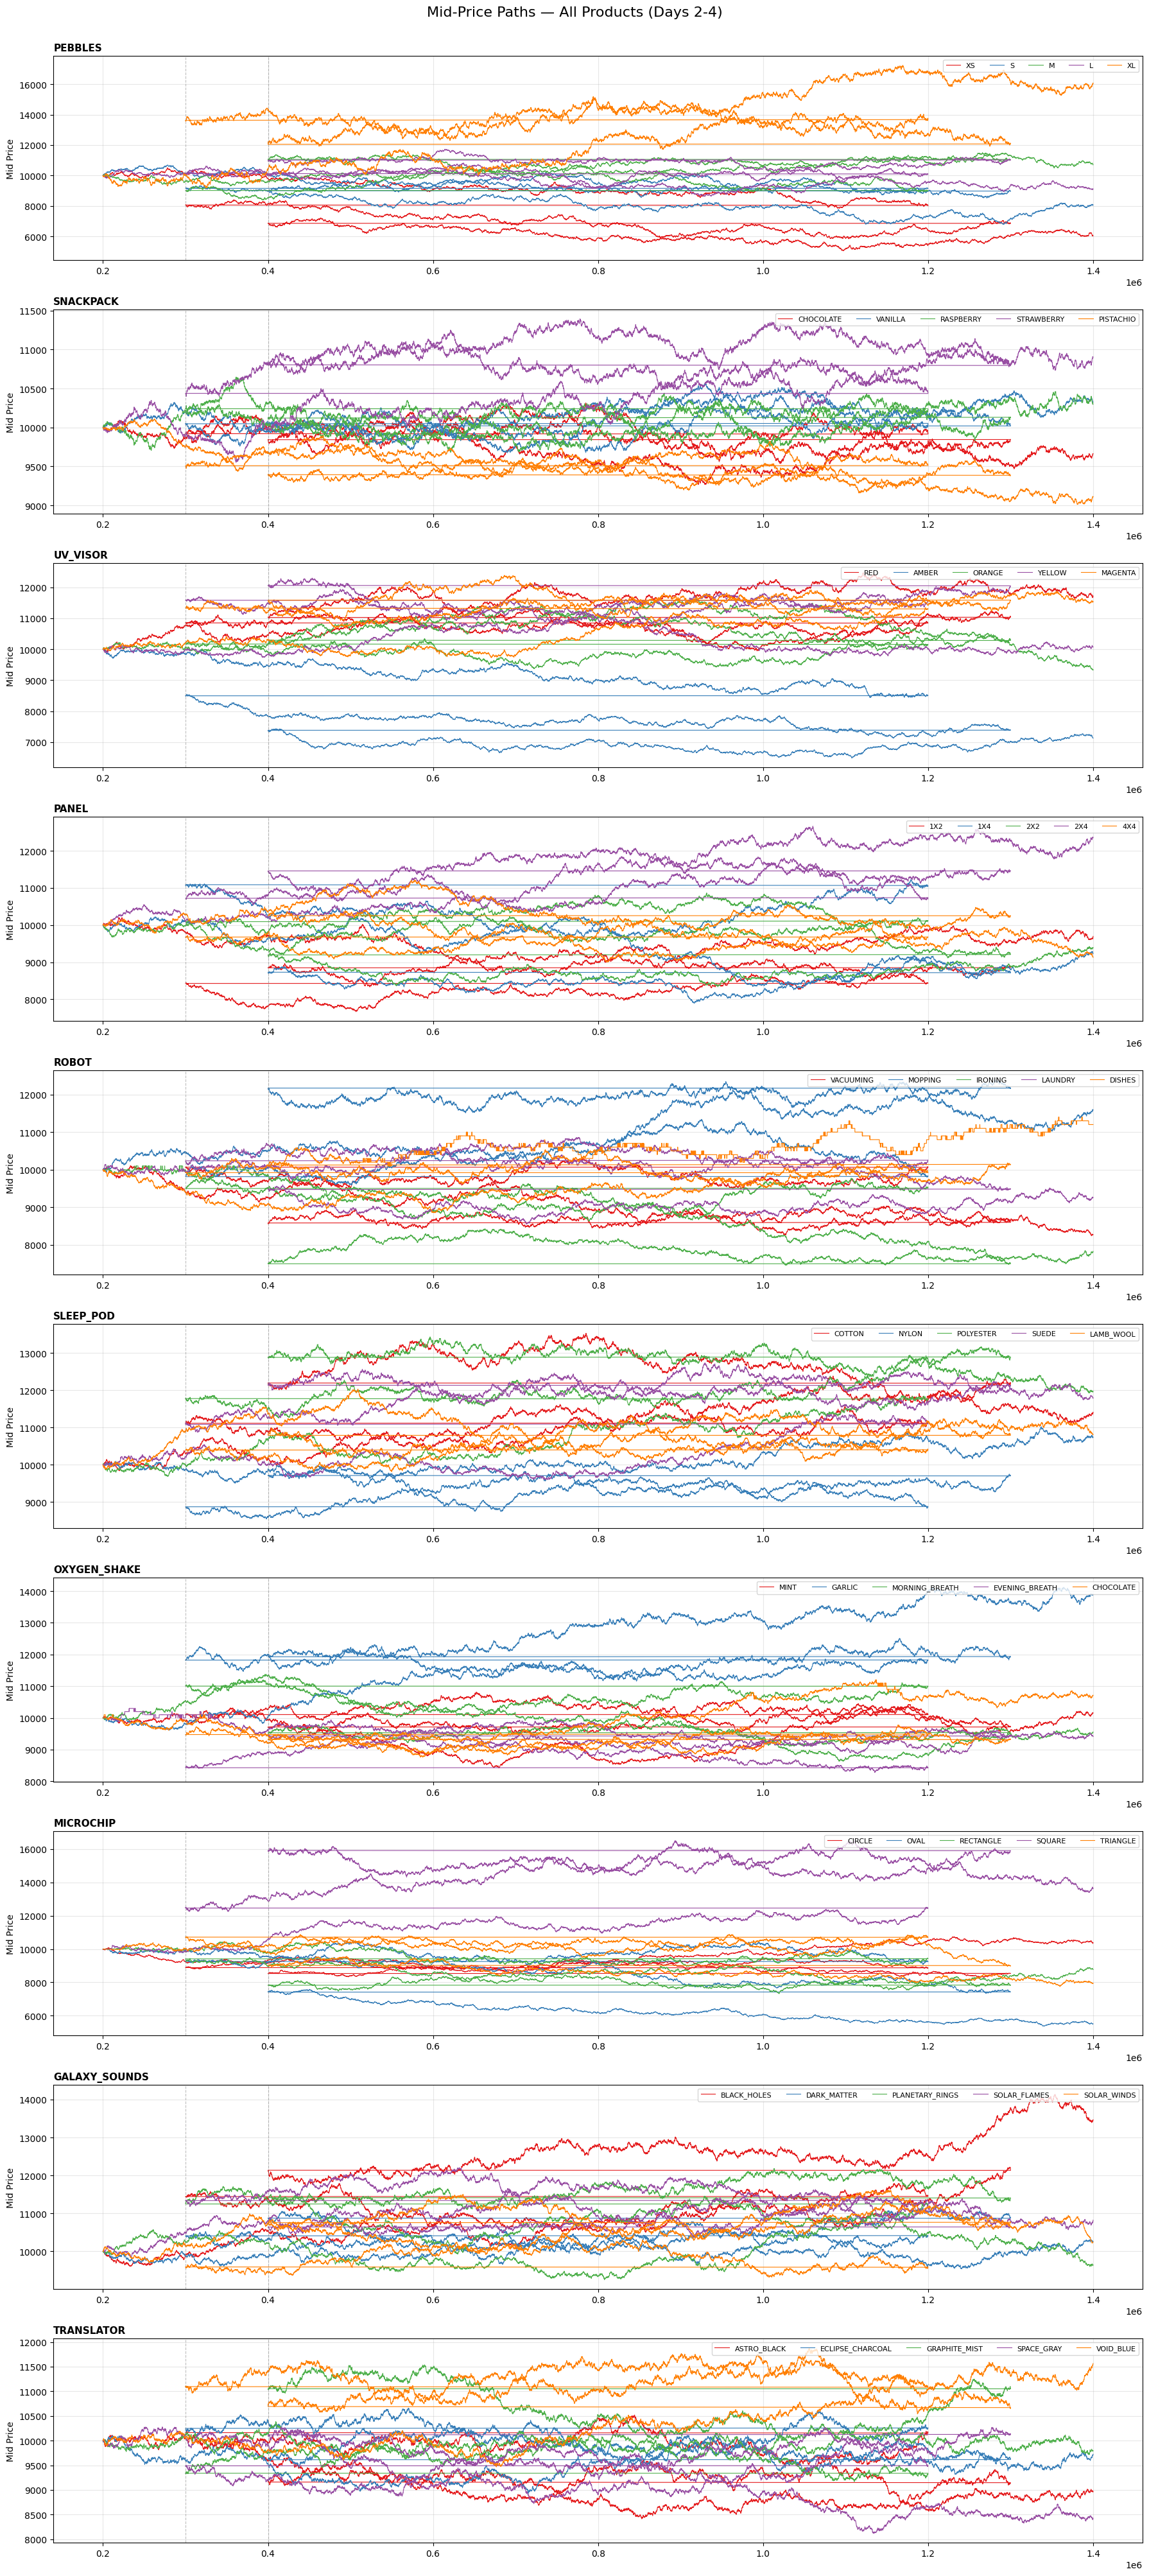

In [4]:
fig, axes = plt.subplots(10, 1, figsize=(18, 40))
fig.suptitle('Mid-Price Paths — All Products (Days 2-4)', fontsize=16, y=1.002)

for ax, (grp, products) in zip(axes, GROUPS.items()):
    for i, p in enumerate(products):
        sub = prices[prices['product']==p].copy()
        sub['x'] = sub['day']*100000 + sub['timestamp']   # continuous x-axis
        ax.plot(sub['x'], sub['mid_price'], color=COLORS[i], lw=0.8, label=p.replace(grp+'_',''))
    ax.set_title(grp, fontsize=11, fontweight='bold', loc='left')
    ax.legend(fontsize=8, ncol=5, loc='upper right')
    ax.set_ylabel('Mid Price')
    ax.grid(alpha=0.3)
    # vertical lines at day boundaries
    for day in [3, 4]:
        ax.axvline(day*100000, color='gray', lw=0.8, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('price_paths.png', dpi=120, bbox_inches='tight')
plt.show()

## 2 — Spread Analysis (bid-ask per product)

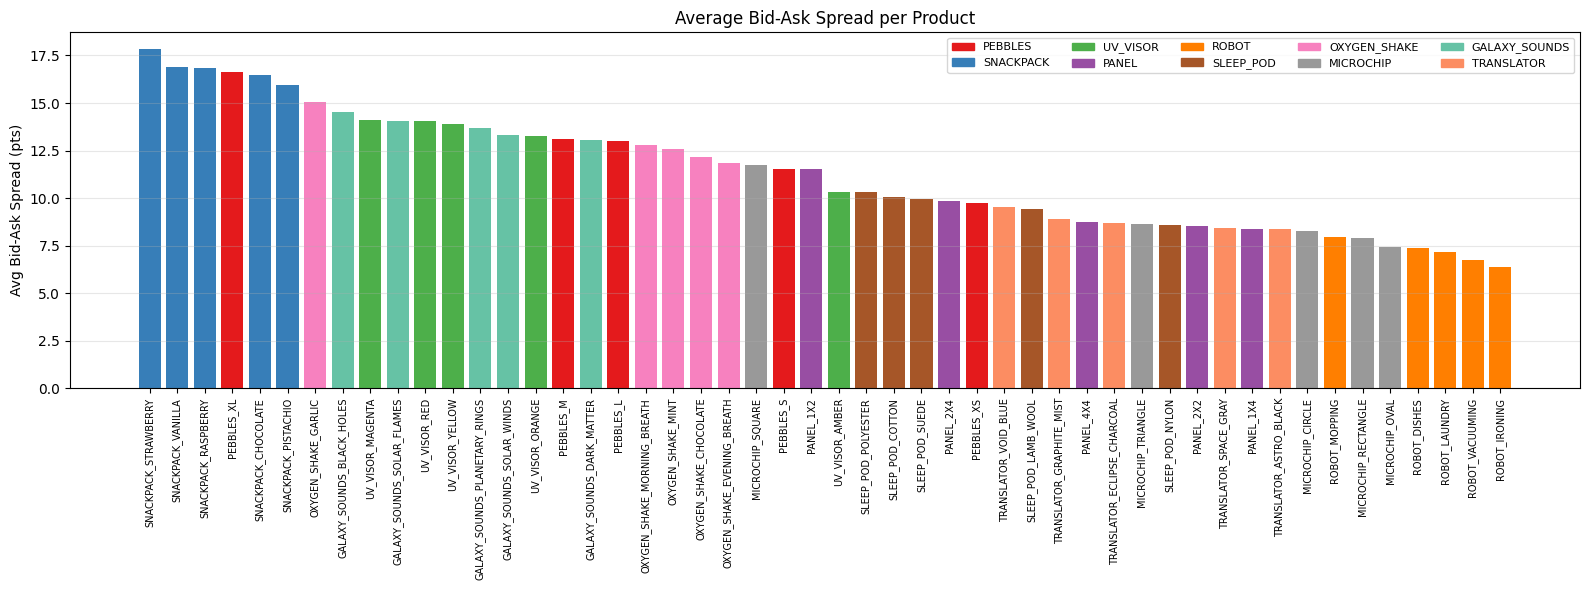

In [5]:
spread_stats = []
for _, row in prices.iterrows():
    if pd.notna(row['bid_price_1']) and pd.notna(row['ask_price_1']):
        spread_stats.append({'product': row['product'],
                             'spread': row['ask_price_1'] - row['bid_price_1']})
spread_df = pd.DataFrame(spread_stats)
spread_avg = spread_df.groupby('product')['spread'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
colors_bar = []
grp_colors = {'PEBBLES':'#e41a1c','SNACKPACK':'#377eb8','UV_VISOR':'#4daf4a',
              'PANEL':'#984ea3','ROBOT':'#ff7f00','SLEEP_POD':'#a65628',
              'OXYGEN_SHAKE':'#f781bf','MICROCHIP':'#999999','GALAXY_SOUNDS':'#66c2a5','TRANSLATOR':'#fc8d62'}
for p in spread_avg.index:
    for grp, prods in GROUPS.items():
        if p in prods: colors_bar.append(grp_colors[grp]); break

ax.bar(range(len(spread_avg)), spread_avg.values, color=colors_bar)
ax.set_xticks(range(len(spread_avg)))
ax.set_xticklabels(spread_avg.index, rotation=90, fontsize=7)
ax.set_ylabel('Avg Bid-Ask Spread (pts)')
ax.set_title('Average Bid-Ask Spread per Product')
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_patches = [Patch(color=v, label=k) for k,v in grp_colors.items()]
ax.legend(handles=legend_patches, fontsize=8, ncol=5)
plt.tight_layout(); plt.savefig('spreads.png', dpi=120, bbox_inches='tight'); plt.show()

## 3 — PEBBLES: Basket Sum Constraint (sum ≈ 50,000)

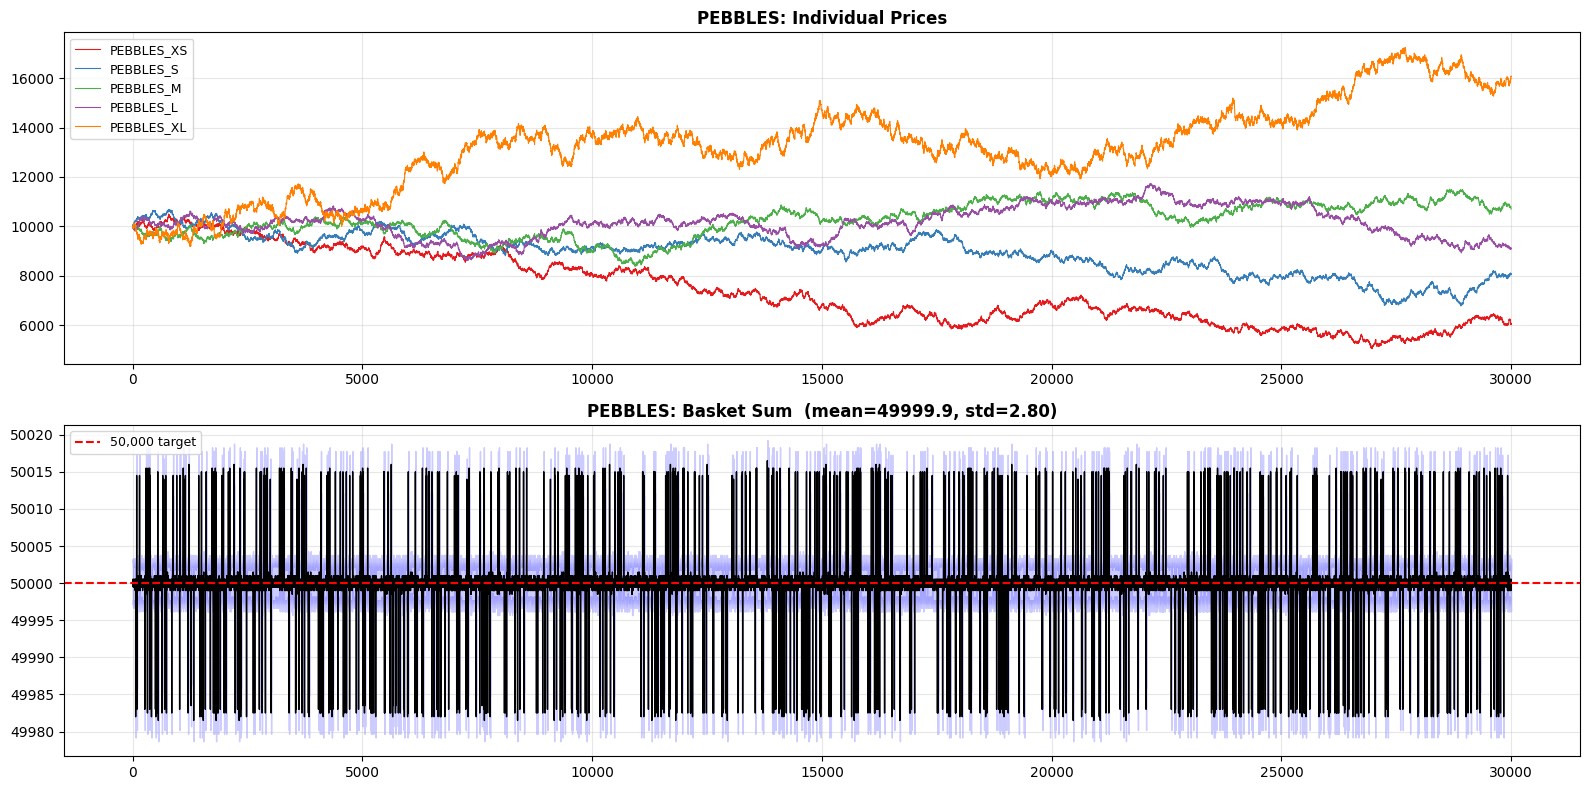

XL prediction error via constraint: std = 2.798 pts


In [6]:
pb = wide[GROUPS['PEBBLES']].dropna()
pb_sum = pb.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Individual prices
for i, p in enumerate(GROUPS['PEBBLES']):
    axes[0].plot(pb[p].values, color=COLORS[i], lw=0.8, label=p)
axes[0].set_title('PEBBLES: Individual Prices', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Basket sum
axes[1].plot(pb_sum.values, color='black', lw=1)
axes[1].axhline(50000, color='red', ls='--', lw=1.5, label='50,000 target')
axes[1].fill_between(range(len(pb_sum)),
                     pb_sum.values - pb_sum.std(),
                     pb_sum.values + pb_sum.std(), alpha=0.2, color='blue')
axes[1].set_title(f'PEBBLES: Basket Sum  (mean={pb_sum.mean():.1f}, std={pb_sum.std():.2f})', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('pebbles_constraint.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'XL prediction error via constraint: std = {(pb["PEBBLES_XL"] - (50000-pb[GROUPS["PEBBLES"][:-1]].sum(axis=1))).std():.3f} pts')

## 4 — SNACKPACK: Pair Structure (CHOC↔VAN, RASP↔PISTACHIO)

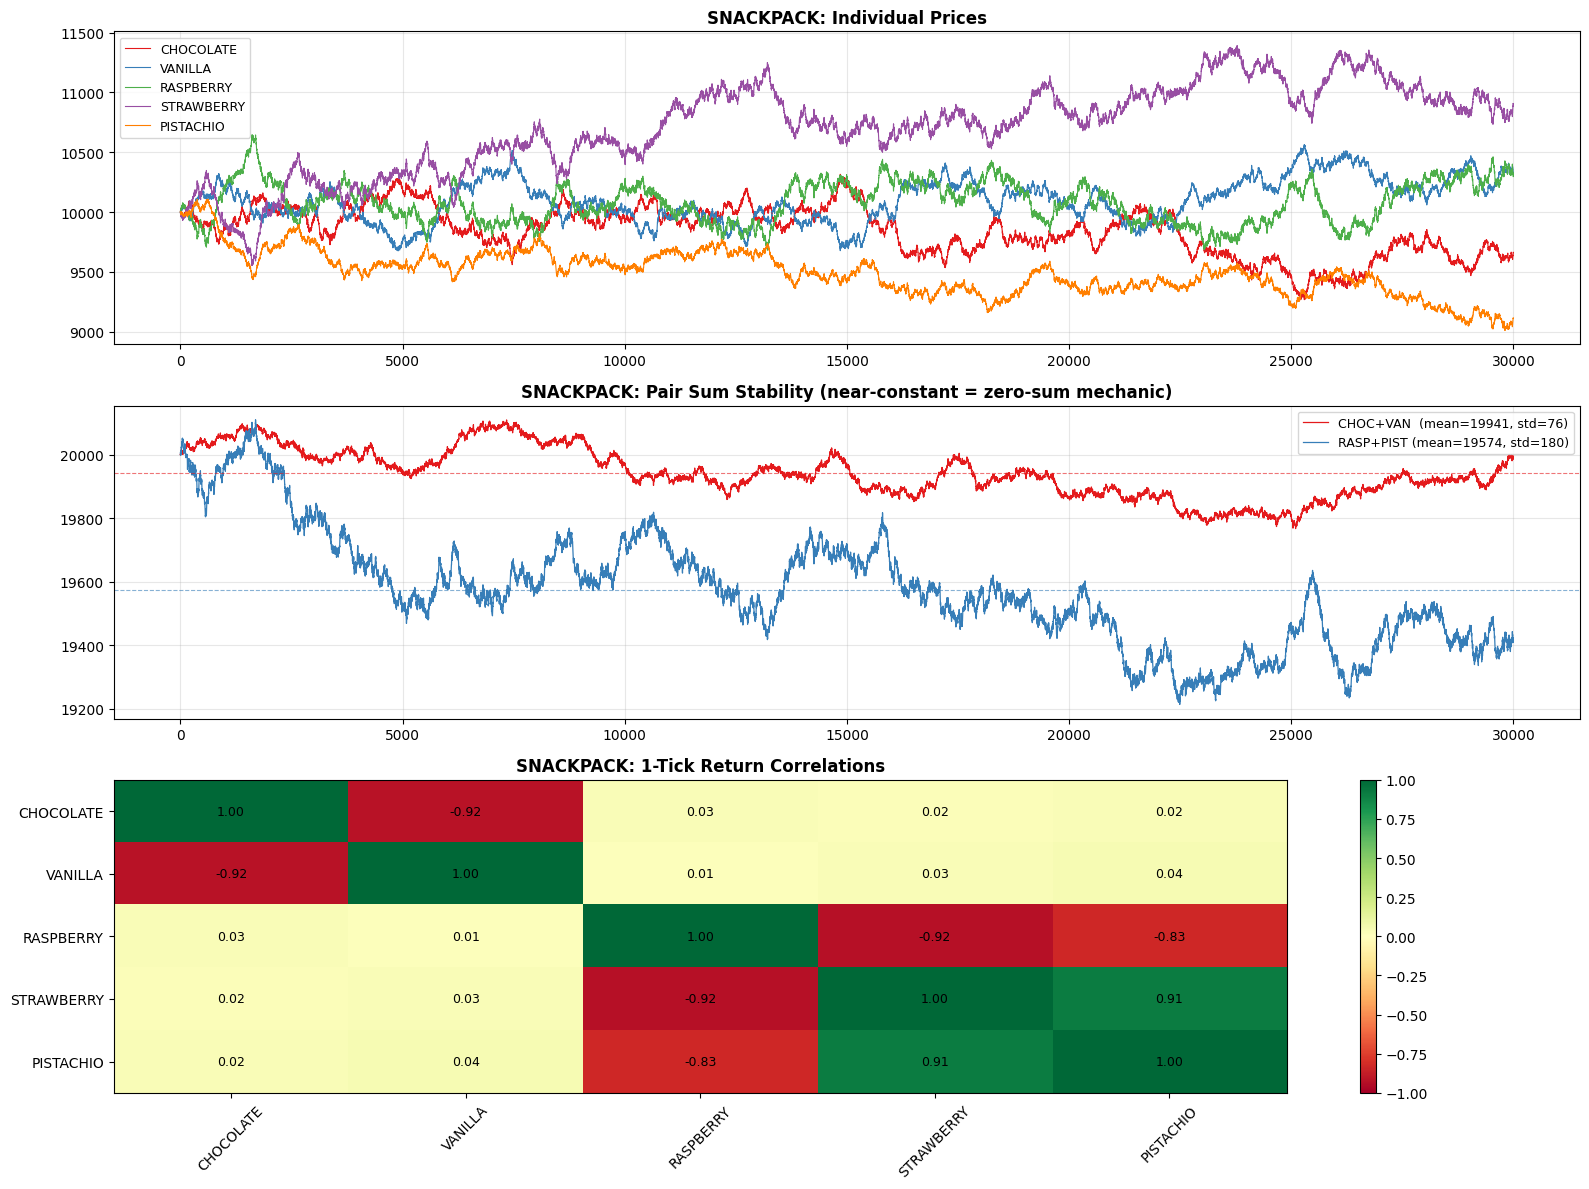

In [7]:
sn = wide[GROUPS['SNACKPACK']].dropna()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Prices
for i, p in enumerate(GROUPS['SNACKPACK']):
    axes[0].plot(sn[p].values, color=COLORS[i], lw=0.8, label=p.replace('SNACKPACK_',''))
axes[0].set_title('SNACKPACK: Individual Prices', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Pair sums
cv_sum = sn['SNACKPACK_CHOCOLATE'] + sn['SNACKPACK_VANILLA']
rp_sum = sn['SNACKPACK_RASPBERRY'] + sn['SNACKPACK_PISTACHIO']
axes[1].plot(cv_sum.values, color='#e41a1c', lw=0.9, label=f'CHOC+VAN  (mean={cv_sum.mean():.0f}, std={cv_sum.std():.0f})')
axes[1].plot(rp_sum.values, color='#377eb8', lw=0.9, label=f'RASP+PIST (mean={rp_sum.mean():.0f}, std={rp_sum.std():.0f})')
axes[1].axhline(cv_sum.mean(), color='#e41a1c', ls='--', lw=0.8, alpha=0.6)
axes[1].axhline(rp_sum.mean(), color='#377eb8', ls='--', lw=0.8, alpha=0.6)
axes[1].set_title('SNACKPACK: Pair Sum Stability (near-constant = zero-sum mechanic)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Return correlations
rets = sn.diff().dropna()
im = axes[2].imshow(rets.corr(), cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
labels = [p.replace('SNACKPACK_','') for p in GROUPS['SNACKPACK']]
axes[2].set_xticks(range(5)); axes[2].set_xticklabels(labels, rotation=45)
axes[2].set_yticks(range(5)); axes[2].set_yticklabels(labels)
for i in range(5):
    for j in range(5):
        axes[2].text(j, i, f'{rets.corr().values[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[2])
axes[2].set_title('SNACKPACK: 1-Tick Return Correlations', fontweight='bold')

plt.tight_layout(); plt.savefig('snackpack_pairs.png', dpi=120, bbox_inches='tight'); plt.show()

## 5 — Per-Group Return Correlation Heatmaps

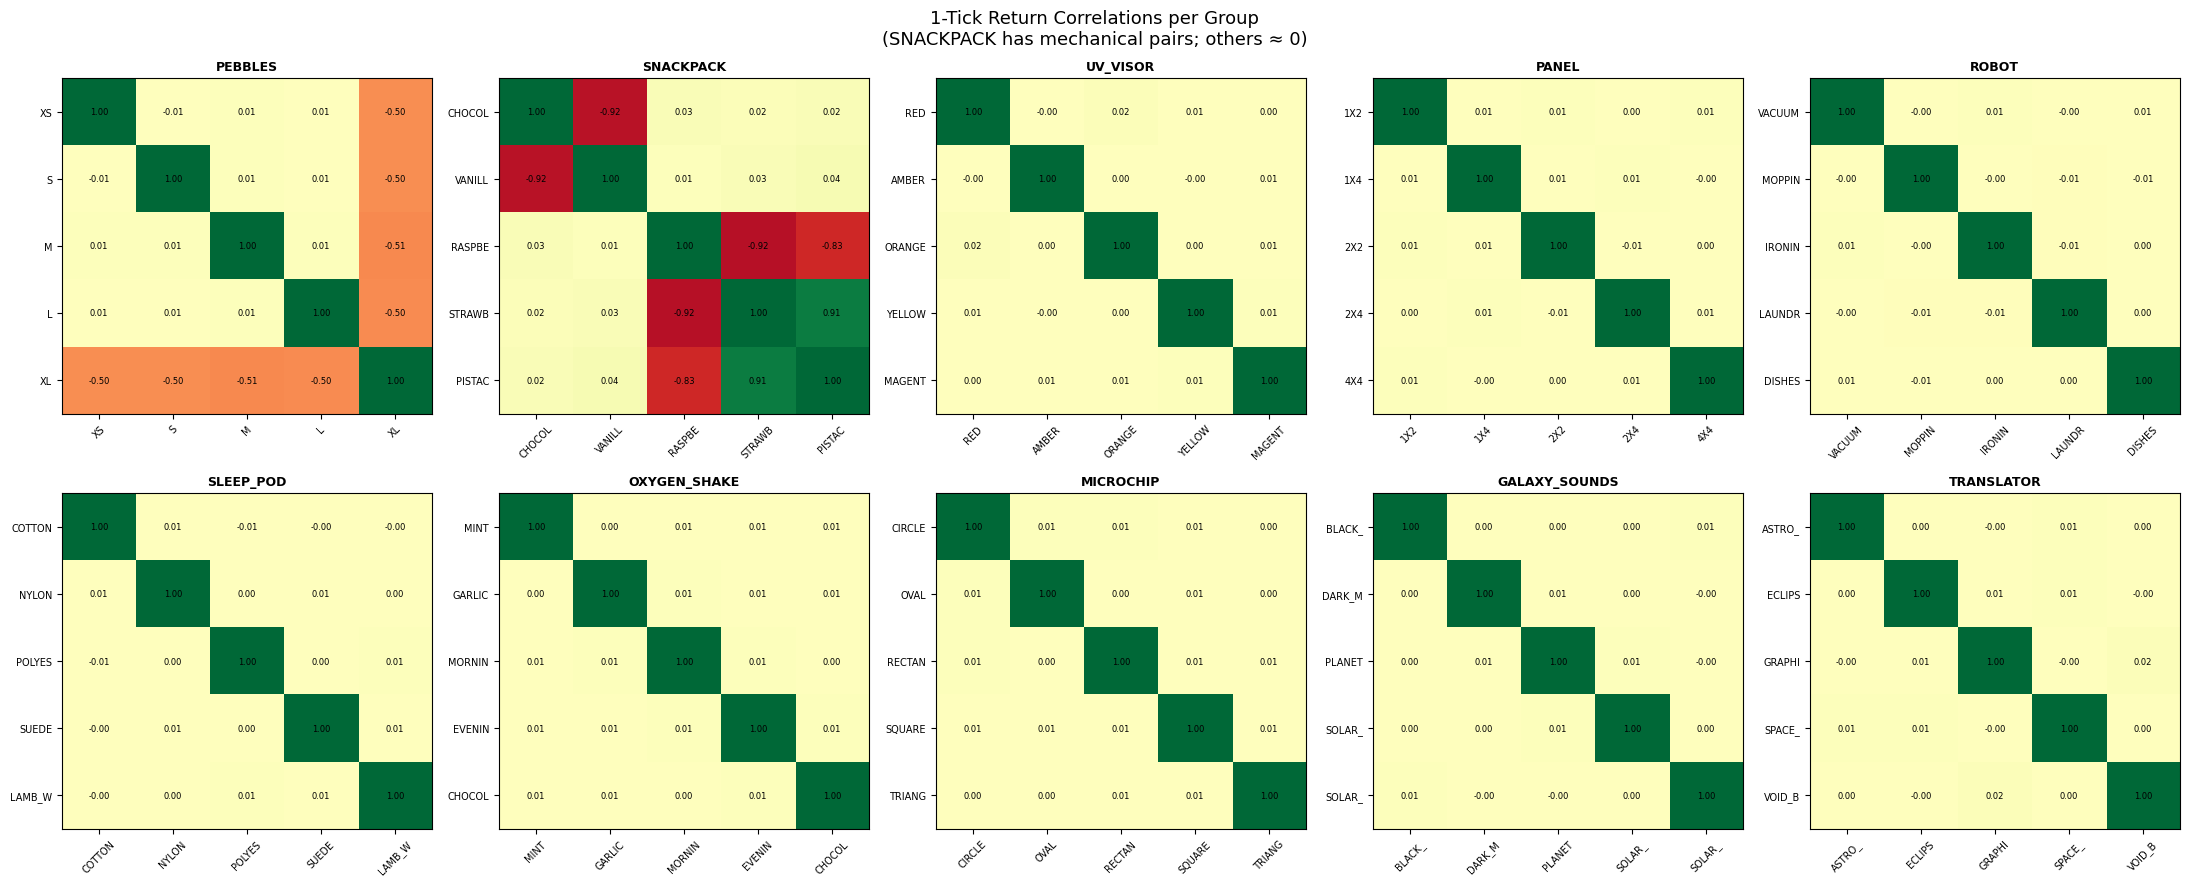

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, (grp, products) in zip(axes, GROUPS.items()):
    sub = wide[products].dropna()
    rets = sub.diff().dropna()
    corr = rets.corr()
    im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    short_labels = [p.replace(grp+'_','').replace('GALAXY_SOUNDS_','').replace('OXYGEN_SHAKE_','')[:6] for p in products]
    ax.set_xticks(range(5)); ax.set_xticklabels(short_labels, fontsize=7, rotation=45)
    ax.set_yticks(range(5)); ax.set_yticklabels(short_labels, fontsize=7)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6)
    ax.set_title(grp, fontweight='bold', fontsize=9)

fig.suptitle('1-Tick Return Correlations per Group\n(SNACKPACK has mechanical pairs; others ≈ 0)', fontsize=13)
plt.tight_layout(); plt.savefig('return_correlations.png', dpi=120, bbox_inches='tight'); plt.show()

## 6 — Per-Group Basket Sum Stability

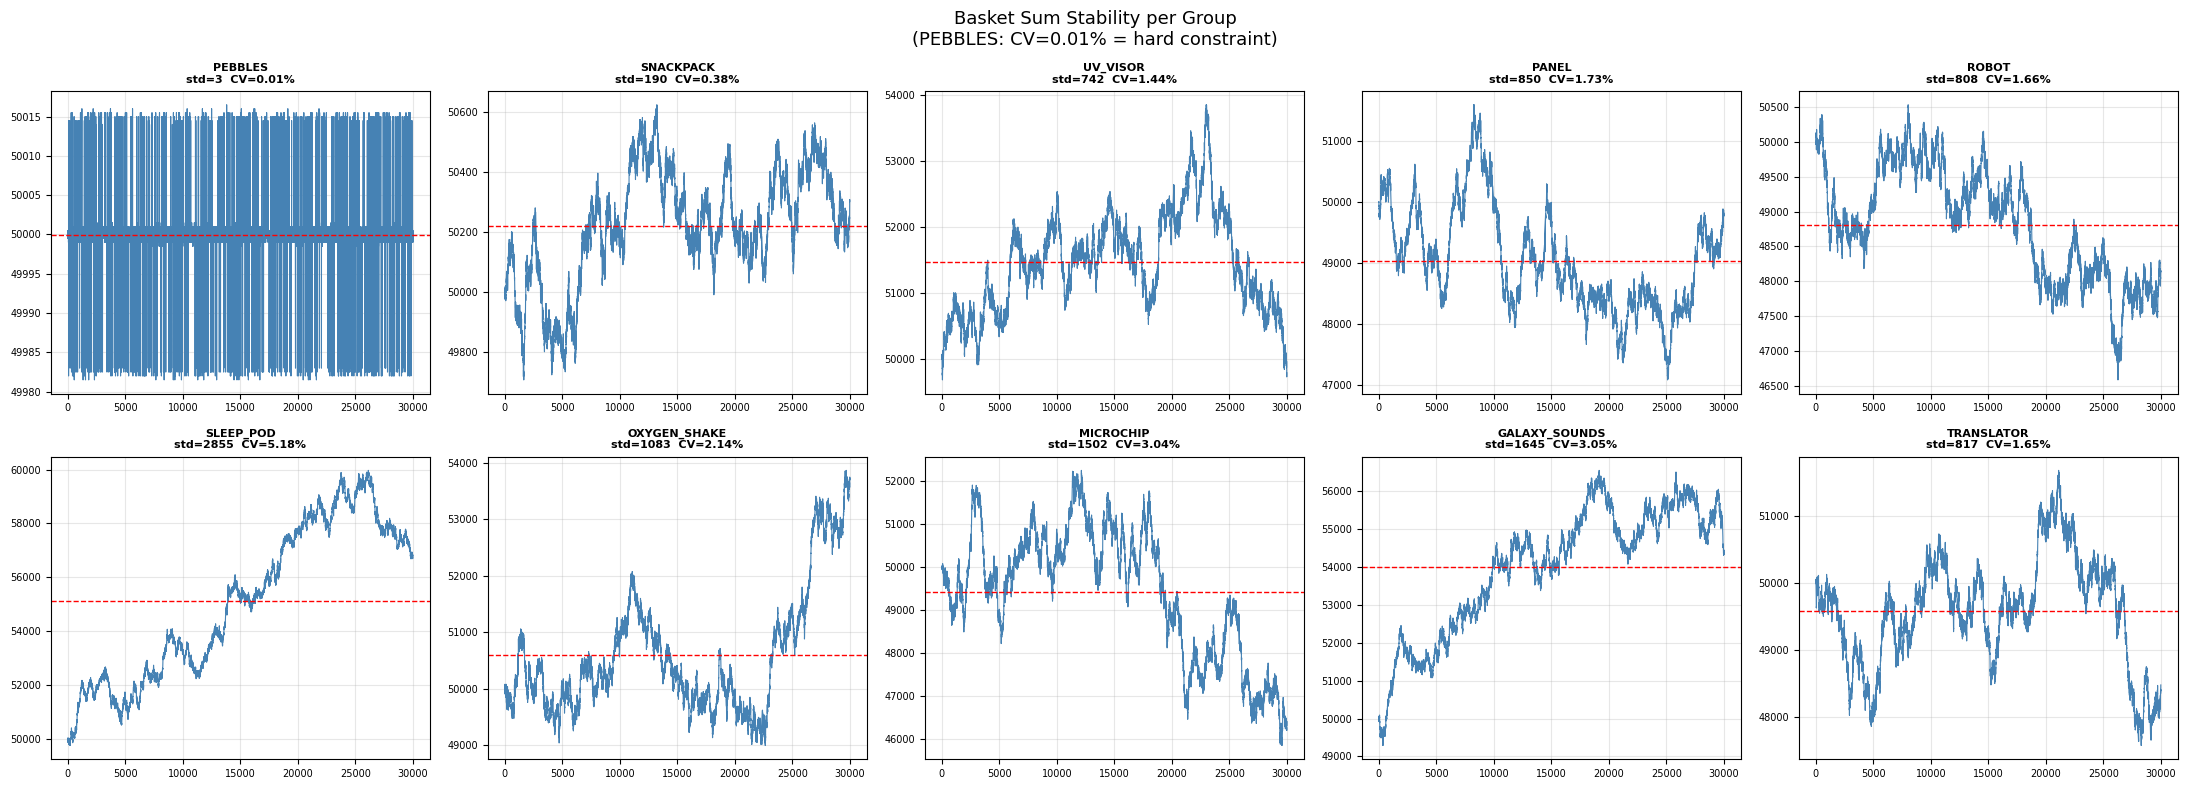

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for ax, (grp, products) in zip(axes, GROUPS.items()):
    sub = wide[products].dropna()
    basket = sub.sum(axis=1)
    ax.plot(basket.values, lw=0.8, color='steelblue')
    ax.axhline(basket.mean(), color='red', ls='--', lw=1)
    cv = basket.std() / basket.mean() * 100
    ax.set_title(f'{grp}\nstd={basket.std():.0f}  CV={cv:.2f}%', fontsize=8, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

fig.suptitle('Basket Sum Stability per Group\n(PEBBLES: CV=0.01% = hard constraint)', fontsize=13)
plt.tight_layout(); plt.savefig('basket_sums.png', dpi=120, bbox_inches='tight'); plt.show()

## 7 — Individual Asset Deep-Dive (price + spread + EMA)

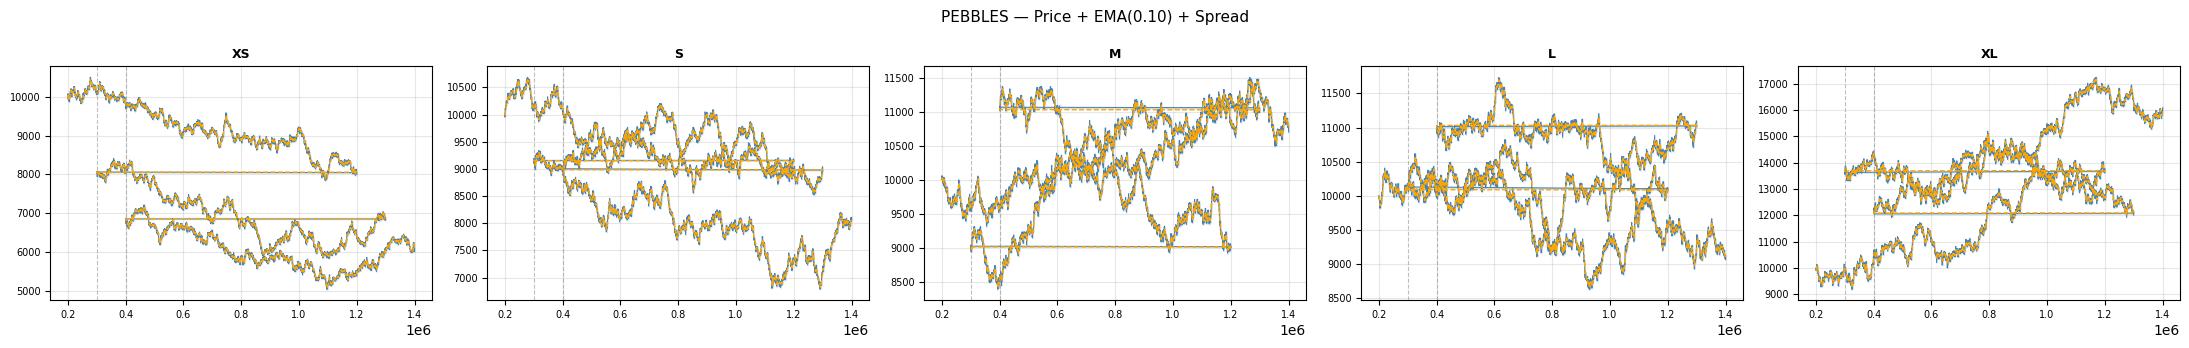

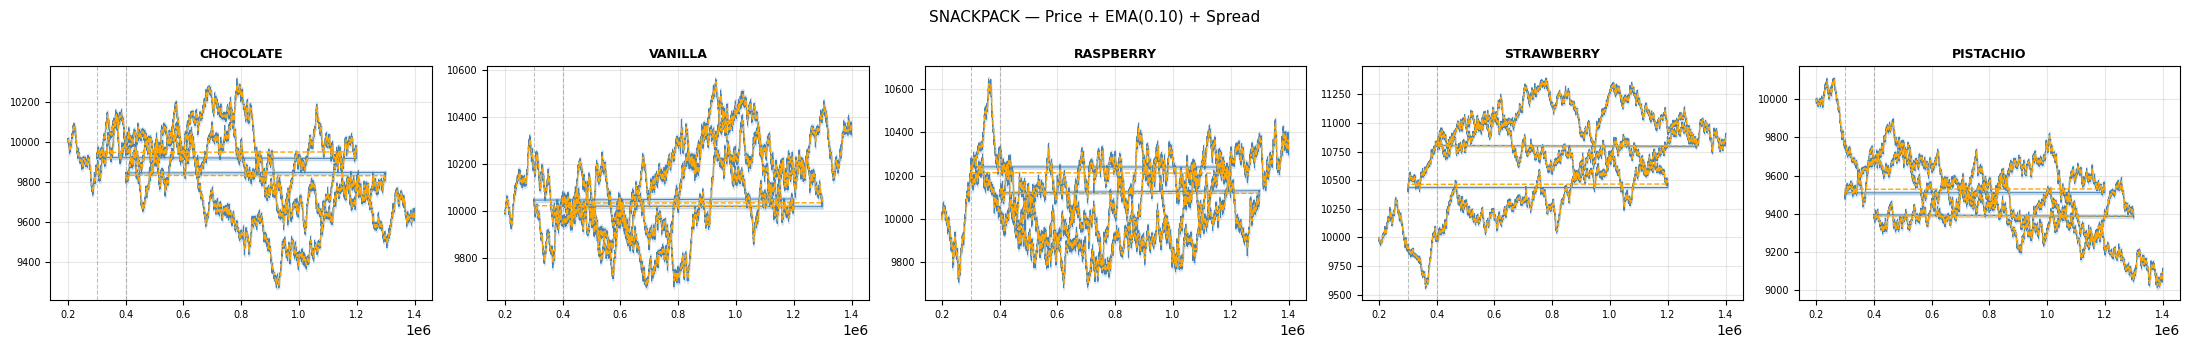

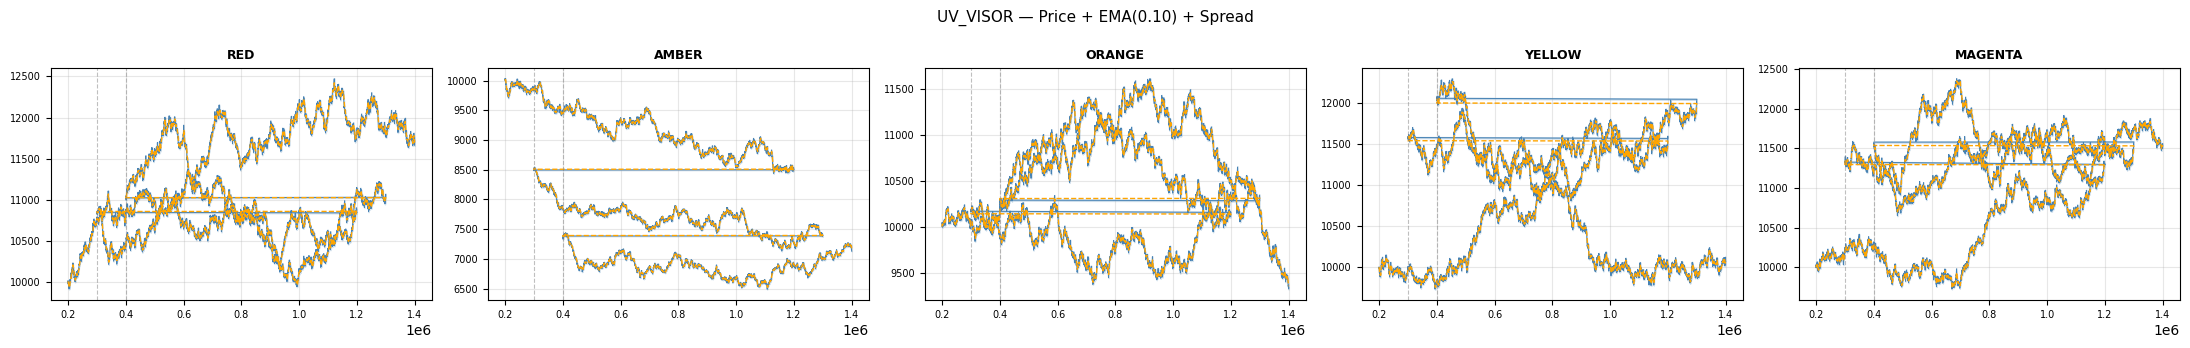

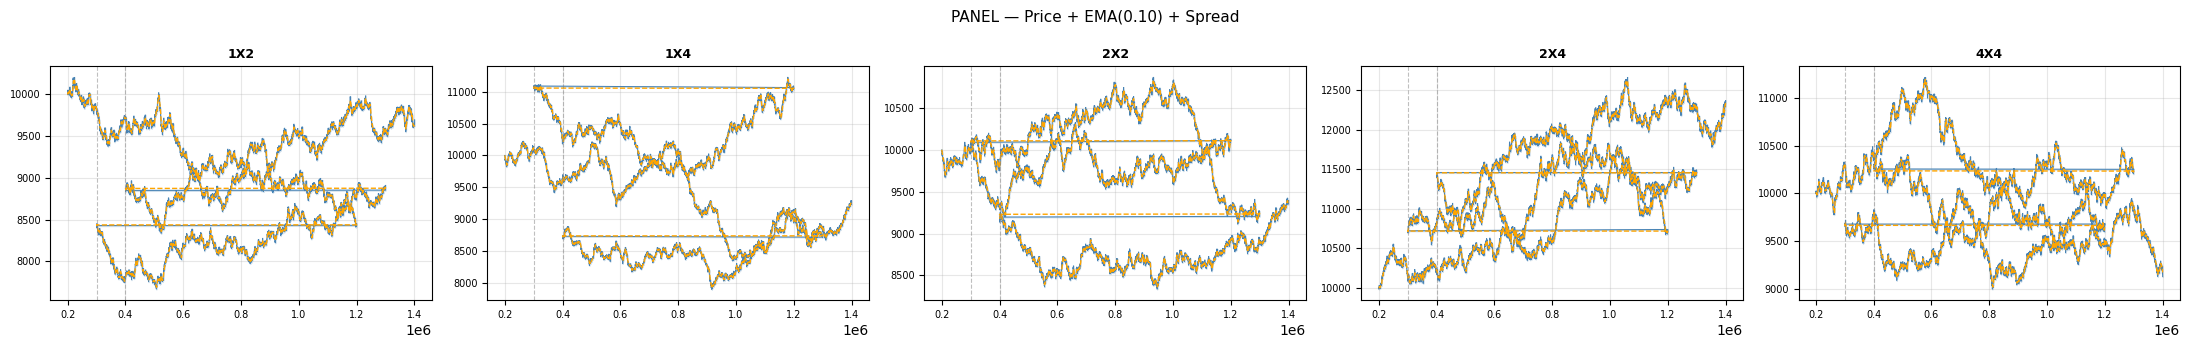

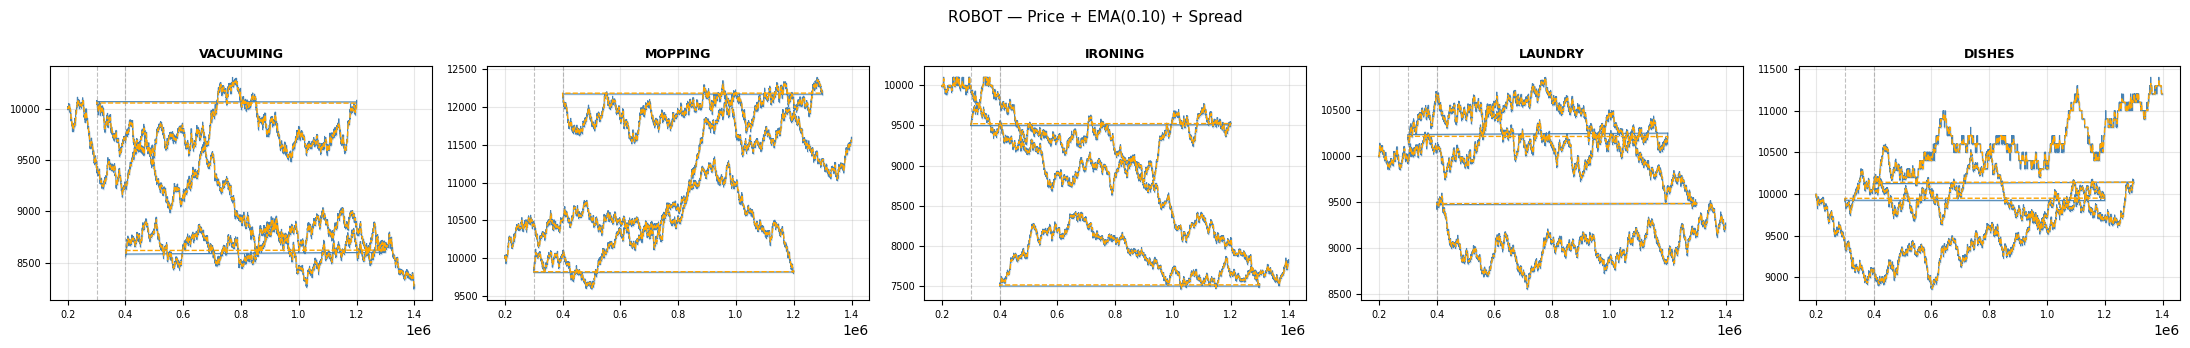

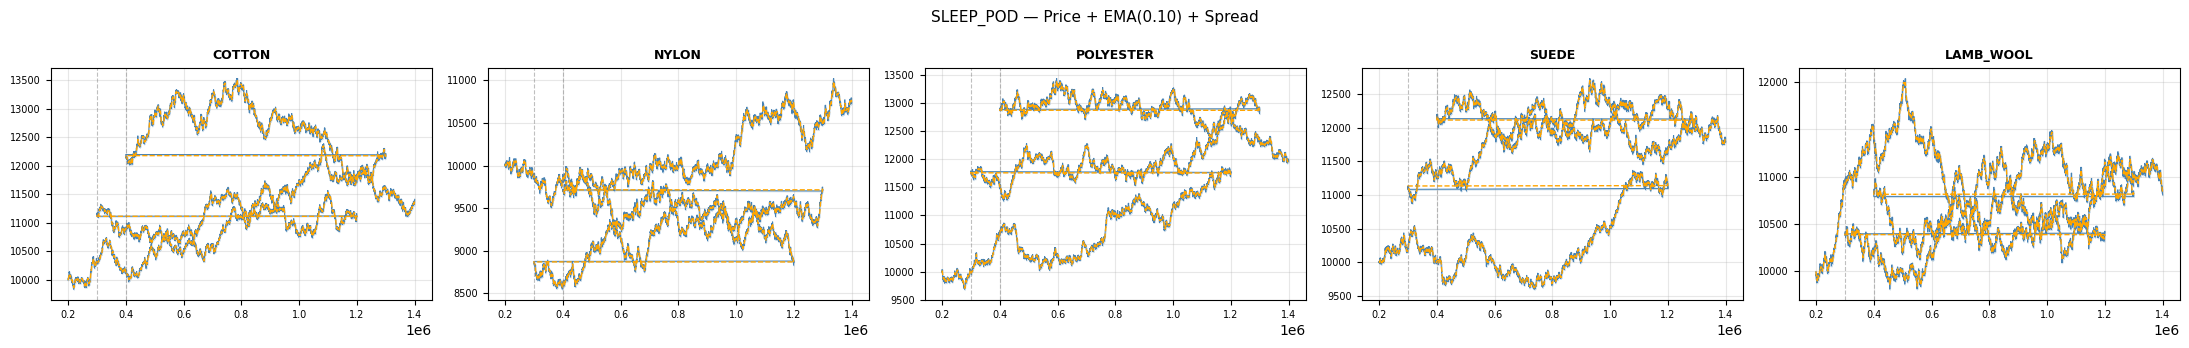

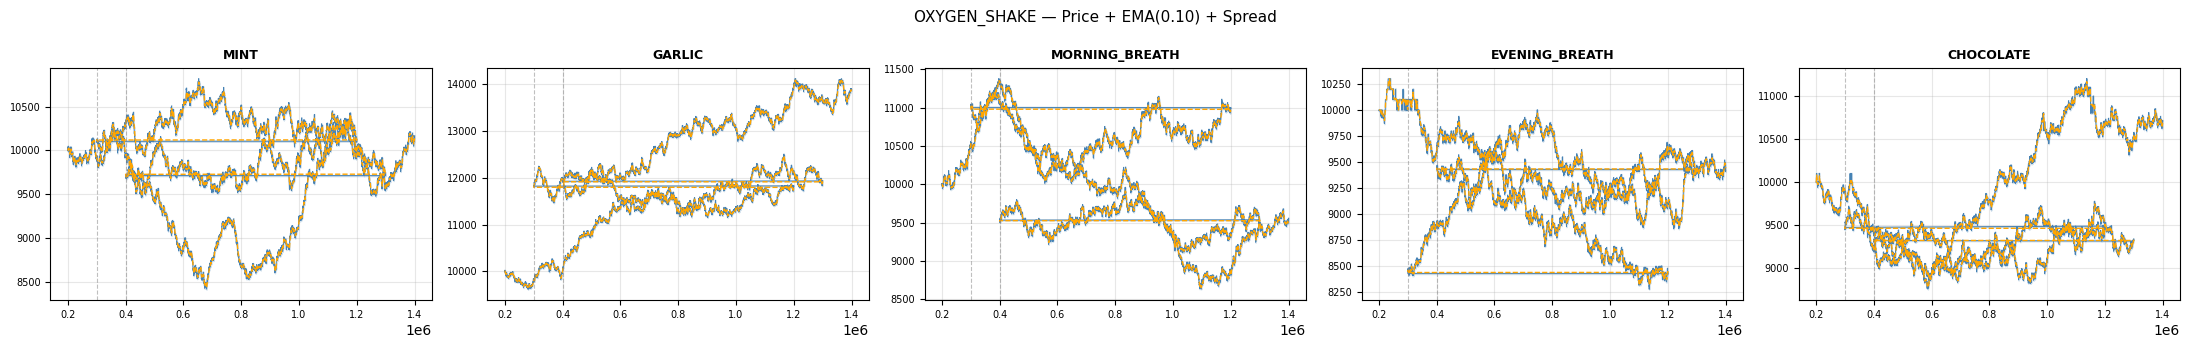

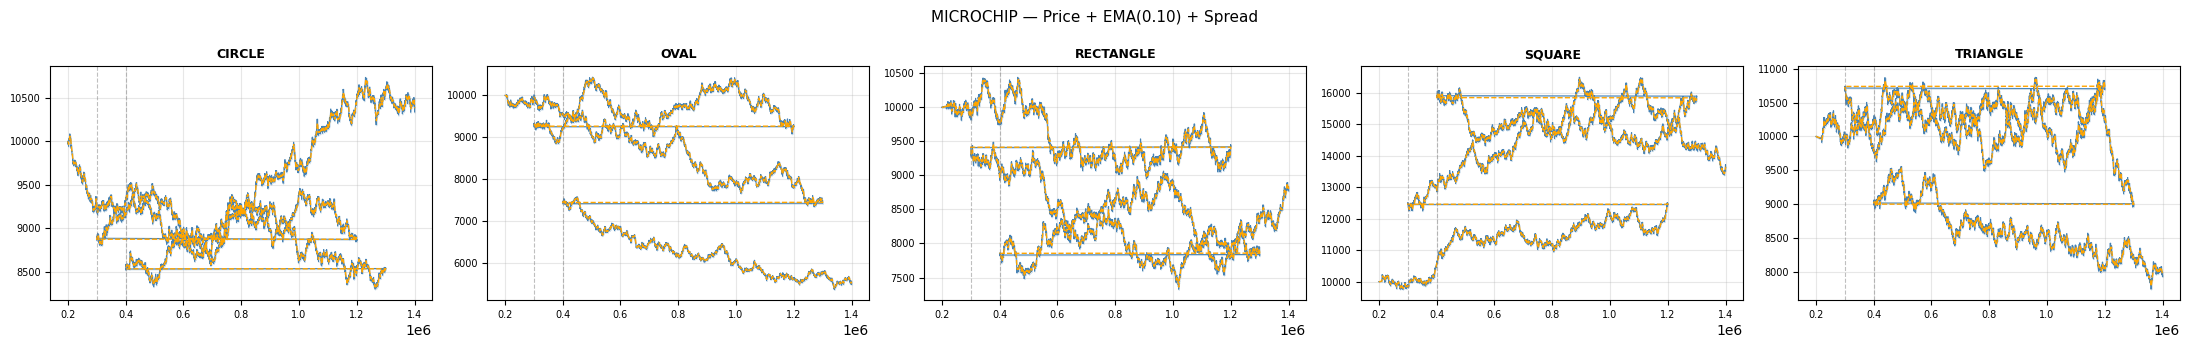

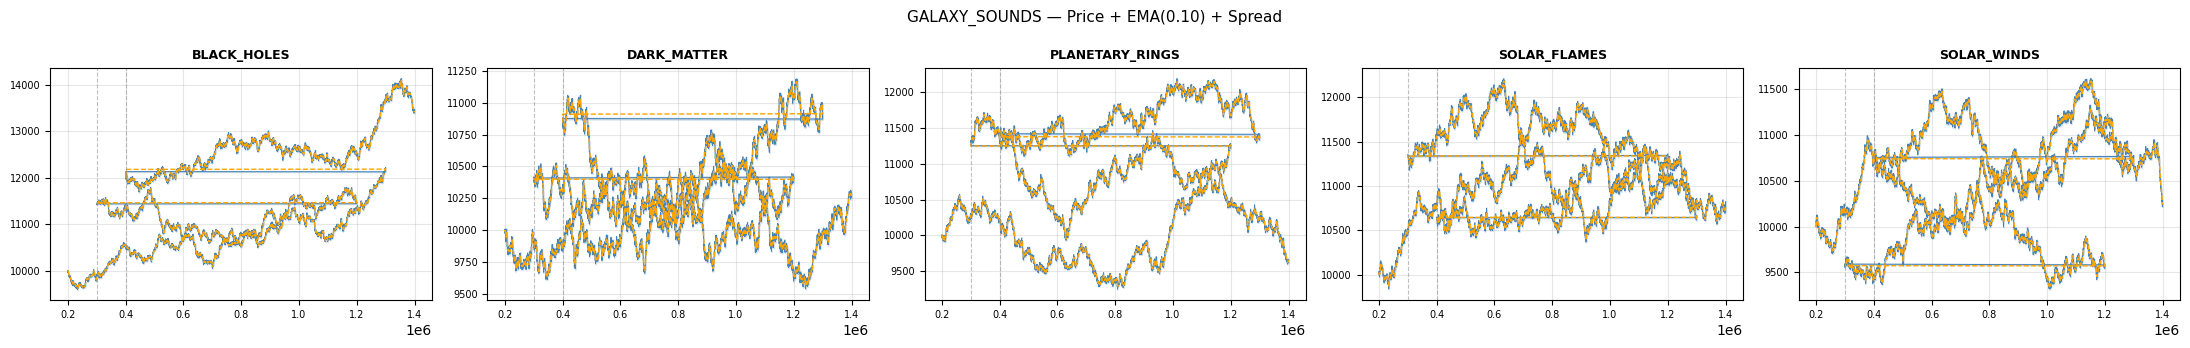

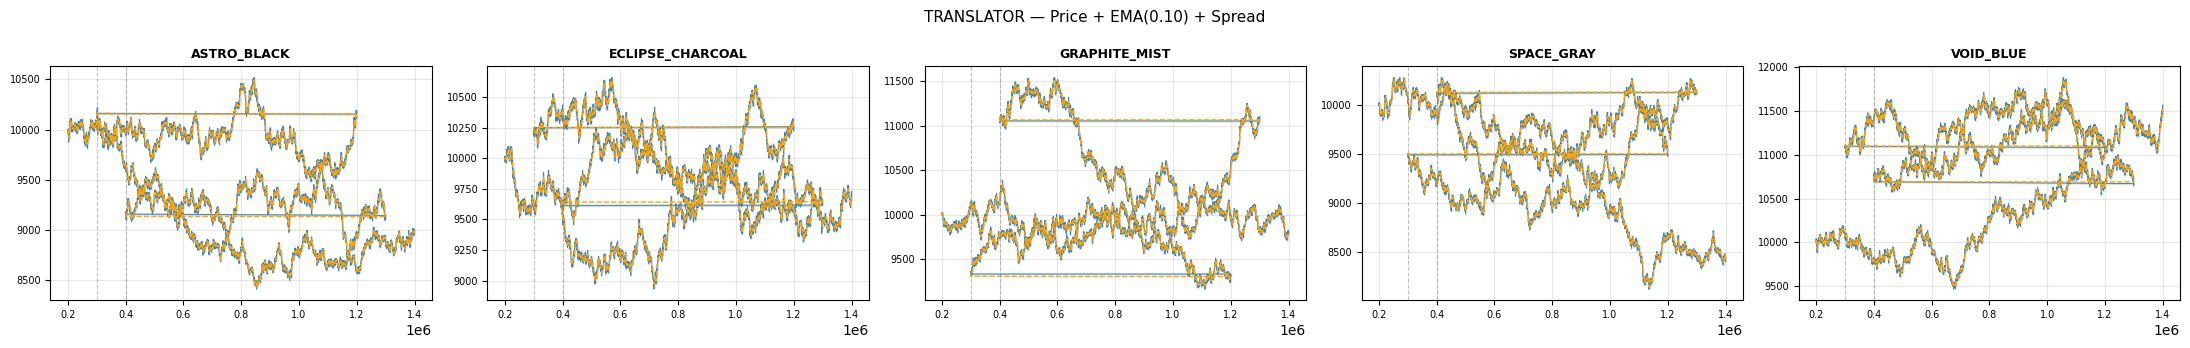

In [10]:
def plot_asset(product, alpha_ema=0.10, ax=None):
    sub = prices[prices['product']==product].sort_values(['day','timestamp']).copy()
    sub['x'] = sub['day'] * 100000 + sub['timestamp']
    sub['spread'] = sub['ask_price_1'] - sub['bid_price_1']
    
    # EMA
    ema = sub['mid_price'].ewm(alpha=alpha_ema, adjust=False).mean()
    
    show = ax is None
    if ax is None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    else:
        ax1 = ax
        ax2 = ax.twinx()
    
    ax1.fill_between(sub['x'], sub['bid_price_1'], sub['ask_price_1'],
                    alpha=0.2, color='steelblue', label='Bid-Ask')
    ax1.plot(sub['x'], sub['mid_price'], color='steelblue', lw=0.8, label='Mid')
    ax1.plot(sub['x'], ema, color='orange', lw=1.2, ls='--', label=f'EMA({alpha_ema})')
    ax1.set_title(product, fontweight='bold')
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
    
    if show:
        ax2.plot(sub['x'], sub['spread'], color='red', lw=0.6, alpha=0.7, label='Spread')
        ax2.set_ylabel('Spread', color='red'); ax2.grid(alpha=0.3)
        ax2.legend(fontsize=8, loc='upper right')
        plt.tight_layout(); plt.show()

# Show each group as a 1×5 grid
for grp, products in GROUPS.items():
    fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
    fig.suptitle(f'{grp} — Price + EMA(0.10) + Spread', fontsize=11)
    for ax, p in zip(axes, products):
        sub = prices[prices['product']==p].sort_values(['day','timestamp']).copy()
        sub['x'] = sub['day'] * 100000 + sub['timestamp']
        ema = sub['mid_price'].ewm(alpha=0.10, adjust=False).mean()
        ax.fill_between(sub['x'], sub['bid_price_1'], sub['ask_price_1'], alpha=0.2, color='steelblue')
        ax.plot(sub['x'], sub['mid_price'], color='steelblue', lw=0.7)
        ax.plot(sub['x'], ema, color='orange', lw=1, ls='--')
        short = p.replace(grp+'_','').replace('GALAXY_SOUNDS_','').replace('OXYGEN_SHAKE_','')
        ax.set_title(short, fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
        # day boundaries
        for day in [3, 4]: ax.axvline(day*100000, color='gray', lw=0.8, ls='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'group_{grp}.png', dpi=110, bbox_inches='tight')
    plt.show()

## 8 — Log File: v1 Actual P&L + Trade Activity (Day 4)

In [11]:
import json, io

log_path = '547962.log'   # place log file in same folder
try:
    log_data = json.loads(open(log_path).read())
    acts = pd.read_csv(io.StringIO(log_data['activitiesLog']), sep=';')
    trades = pd.DataFrame(log_data['tradeHistory'])
    
    # P&L per product
    final_pnl = acts.groupby('product')['profit_and_loss'].last().sort_values()
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Bar: final PnL per product
    colors_bar = ['#d73027' if v < 0 else '#1a9850' for v in final_pnl.values]
    axes[0].barh(range(len(final_pnl)), final_pnl.values, color=colors_bar)
    axes[0].set_yticks(range(len(final_pnl)))
    axes[0].set_yticklabels(final_pnl.index, fontsize=7)
    axes[0].axvline(0, color='black', lw=0.8)
    axes[0].set_title(f'v1 Day 4 P&L per Product  (total: {final_pnl.sum():.0f})', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Line: cumulative total PnL over time
    cum = acts.groupby('timestamp')['profit_and_loss'].sum()
    axes[1].plot(cum.index, cum.values, color='steelblue', lw=1.2)
    axes[1].fill_between(cum.index, 0, cum.values,
                         where=cum.values<0, alpha=0.3, color='red')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('v1 Cumulative P&L (Day 4)', fontweight='bold')
    axes[1].set_xlabel('Timestamp'); axes[1].set_ylabel('P&L')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('v1_pnl.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Total Day 4 P&L: {final_pnl.sum():.0f}')
except FileNotFoundError:
    print('Log file not found — place 547962.log in the same folder and rerun.')

Log file not found — place 547962.log in the same folder and rerun.


## 9 — V1 Bug Demo: EMA Lag Causes Bad Passive Bids

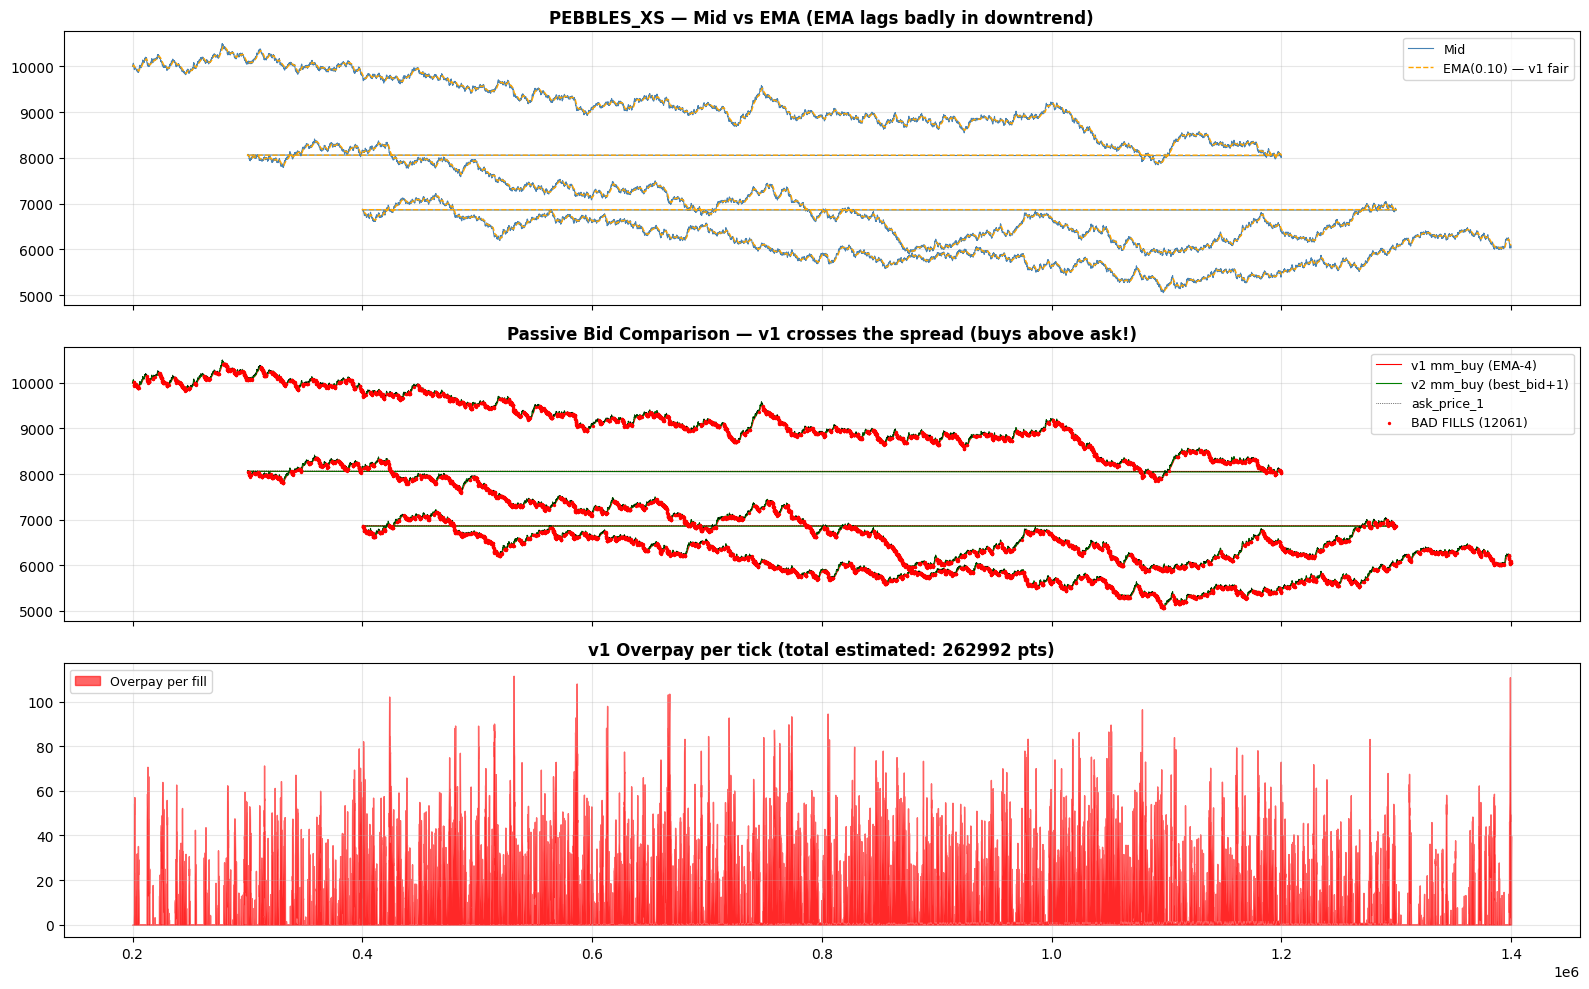

In [12]:
# Illustrate the stale-EMA bid bug on PEBBLES_XS (strong downtrend)
product = 'PEBBLES_XS'
sub = prices[prices['product']==product].sort_values(['day','timestamp']).copy()
sub['x'] = sub['day']*100000 + sub['timestamp']
ema_v1 = sub['mid_price'].ewm(alpha=0.10, adjust=False).mean()

mm_buy_v1 = ema_v1 - 4   # EMA-based bid
mm_buy_v2 = sub['bid_price_1'] + 1  # book-based bid
bad_mask  = mm_buy_v1 > sub['ask_price_1']  # we'd cross the spread!

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(sub['x'], sub['mid_price'],   color='steelblue', lw=0.8, label='Mid')
axes[0].plot(sub['x'], ema_v1, color='orange', lw=1, ls='--', label='EMA(0.10) — v1 fair')
axes[0].set_title('PEBBLES_XS — Mid vs EMA (EMA lags badly in downtrend)', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(sub['x'], mm_buy_v1, color='red',   lw=0.8, label='v1 mm_buy (EMA-4)')
axes[1].plot(sub['x'], mm_buy_v2, color='green', lw=0.8, label='v2 mm_buy (best_bid+1)')
axes[1].plot(sub['x'], sub['ask_price_1'], color='black', lw=0.5, ls=':', label='ask_price_1')
axes[1].scatter(sub['x'][bad_mask], sub['ask_price_1'][bad_mask],
                color='red', s=2, zorder=5, label=f'BAD FILLS ({bad_mask.sum()})')
axes[1].set_title('Passive Bid Comparison — v1 crosses the spread (buys above ask!)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Overpay per tick
overpay = (mm_buy_v1 - sub['ask_price_1']).clip(lower=0)
axes[2].fill_between(sub['x'], 0, overpay, color='red', alpha=0.6, label='Overpay per fill')
axes[2].set_title(f'v1 Overpay per tick (total estimated: {overpay.sum():.0f} pts)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('v1_bug.png', dpi=120, bbox_inches='tight'); plt.show()

## 10 — Strategy Summary Table

        Group  Basket_CV%  Max_TickCorr  AvgSpread       Strategy
      PEBBLES        0.01         0.512       12.8 Constraint arb
    SNACKPACK        0.38         0.924       16.8    Pair-sum MM
     UV_VISOR        1.44         0.020       13.1  Book-based MM
        PANEL        1.73         0.010        9.4  Book-based MM
        ROBOT        1.66         0.012        7.1  Book-based MM
    SLEEP_POD        5.18         0.009        9.7  Book-based MM
 OXYGEN_SHAKE        2.14         0.013       12.9  Book-based MM
    MICROCHIP        3.04         0.013        8.8  Book-based MM
GALAXY_SOUNDS        3.05         0.014       13.7  Book-based MM
   TRANSLATOR        1.65         0.018        8.8  Book-based MM


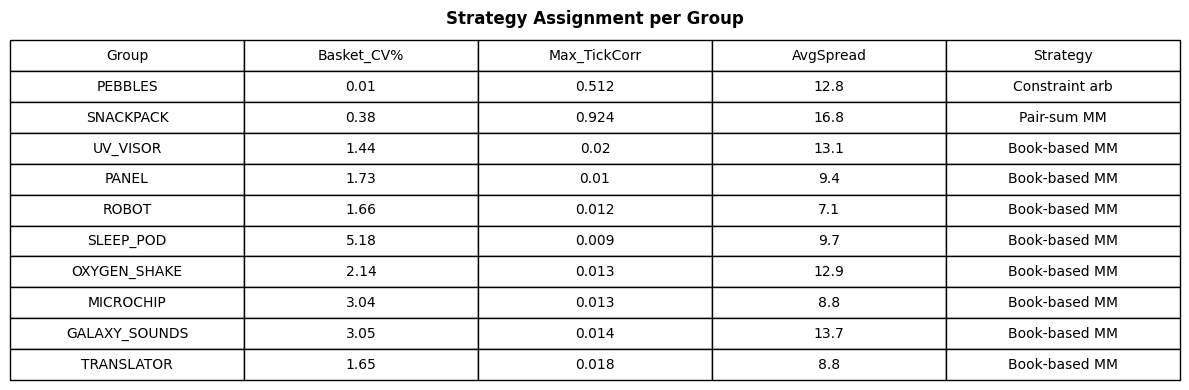

In [13]:
summary = []
for grp, products in GROUPS.items():
    sub = wide[products].dropna()
    basket_sum = sub.sum(axis=1)
    rets = sub.diff().dropna()
    
    # Max pairwise 1-tick return corr
    corr = rets.corr()
    max_abs_corr = max(abs(corr.values[i,j]) for i in range(5) for j in range(5) if i!=j)
    
    basket_cv = basket_sum.std()/basket_sum.mean()*100
    avg_spread = prices[prices['product'].isin(products)].copy()
    avg_spread = (avg_spread['ask_price_1'] - avg_spread['bid_price_1']).mean()
    
    summary.append({'Group': grp,
                    'Basket_CV%': round(basket_cv, 2),
                    'Max_TickCorr': round(max_abs_corr, 3),
                    'AvgSpread': round(avg_spread, 1),
                    'Strategy': 'Constraint arb' if basket_cv < 0.05 else
                                'Pair-sum MM' if max_abs_corr > 0.8 else
                                'Book-based MM'})

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

# Pretty display
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(cellText=summary_df.values,
                 colLabels=summary_df.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(True)
table.scale(1, 1.8)
plt.title('Strategy Assignment per Group', fontweight='bold', pad=20)
plt.tight_layout(); plt.savefig('strategy_table.png', dpi=120, bbox_inches='tight'); plt.show()